# Analysis of the results from MGSD tests

MGSD dataset separated in 2 in-context learning strategies studied for role playing (click links to jump to section):

- [Zero-shot results analysis](#Zero-shot)

- [Few-shot results analysis](#Few-shot)

- [Chain-of-Thoughts results analysis](#Chain-of-Thoughts)

In [ ]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
from datasets import load_dataset
import pandas as pd

## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

# Zero-shot
### Analysis results zero-shot - stereotype detection

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case)




# Few-shot  
## Analysis results few-shot - stereotype detection

In [ ]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern= f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary = run_full_preliminary_analysis(merged_df, 
                                                    case=stereotypes_case,
                                                    df = sample_mgsd, 
                                                    person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, 
                                       case=stereotypes_case, 
                                       group_keys=("gender", "ethnicity", "age"), 
                                       person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=stereotypes_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, 
                                       case=stereotypes_case,
                                       )

# Chain-of-Thoughts
### Analysis results zero-shot - stereotype detection

In [20]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.stereotypes_case import stereotypes_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_stereotype_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_stereotype_optimized_cot.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 15 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile41', 'profile42', 'profile43', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59']


Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 15/15
[INFO] 45 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 15
Significant Differences Found: 2
Statistical Significance Rate: 13.3%

LARGEST EFFECT SIZES
----------------------------------------
 1. age_age.age_1_vs_age.age_5          Effect Size: -4.243 (Large)
 2. indian_vs_middle_eastern            Effect Size:  2.735 (Large)
 3. age_age.age_1_vs_age.age_4          Effect Size: -1.940 (Large)
 4. age_age.age_1_vs_age.age_2          Effect Size: -1.463 (Large)
 5. men_vs_women                        Effect Size: -1.432 (Large)

DETAILED SIGNIFICANT RESULTS
[SIGNIFICANT] men_vs_women                        | Man: 0.739 |

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1577: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  plt.Rectangle((0,0),1,1, color=ethnicity_colors[eth], alpha=0.8, edgecolor="black")


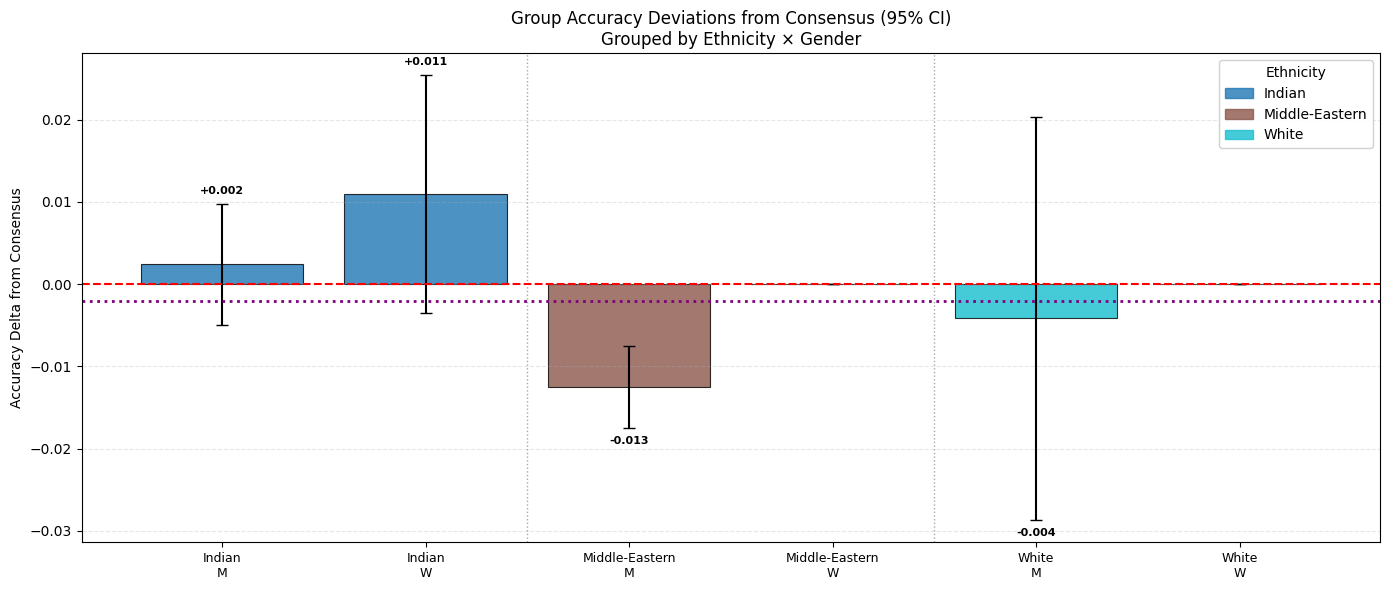


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
indian_man          +0.002    [-0.005, +0.010]5    
indian_woman        +0.011    [-0.004, +0.025]4    
middle_eastern_man  -0.013    [-0.017, -0.008]3    
middle_eastern_woman+0.000    [+0.000, +0.000]0    
white_man           -0.004    [-0.029, +0.020]3    
white_woman         +0.000    [+0.000, +0.000]0    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: stereotype
Category columns analyzed: ['stereotype_type']
Missing category columns: []
Total profiles: 15
Group keys used: ('gender', 'ethnicity', 'age')


In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

results_cot = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df, case=stereotypes_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.stereotypes_case import stereotypes_case

result_tier3_cot = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case)